In [101]:
'''
PI : Ciencia de Datos con Python
Módulo : Análisis de datos con Python
Sesión : Semana 2 - Análisis Descriptivo de Datos
Fecha : Diciembre 2025
Actualización : 30/05/2026
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from scipy import stats

### 1.- Cargando los datos, mostrando tipos de datos y eliminando valores nulos

In [102]:
df = pd.read_csv("dataset/autos_sin_nan.csv")
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


In [103]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object

In [104]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               4
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    1
diesel               0
gas                  0
dtype: int64

In [105]:
df.dropna(axis=0, inplace=True)

In [106]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
city-L/100km         0
horsepower-binned    0
diesel               0
gas                  0
dtype: int64

# A.- Estadística descriptiva

### 2.- Seleccionando variables y realizando gráficos de estas

In [107]:
var_numericas = df.select_dtypes(include=['int64', 'float64']).columns
var_numericas

Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'city-L/100km', 'diesel', 'gas'],
      dtype='object')

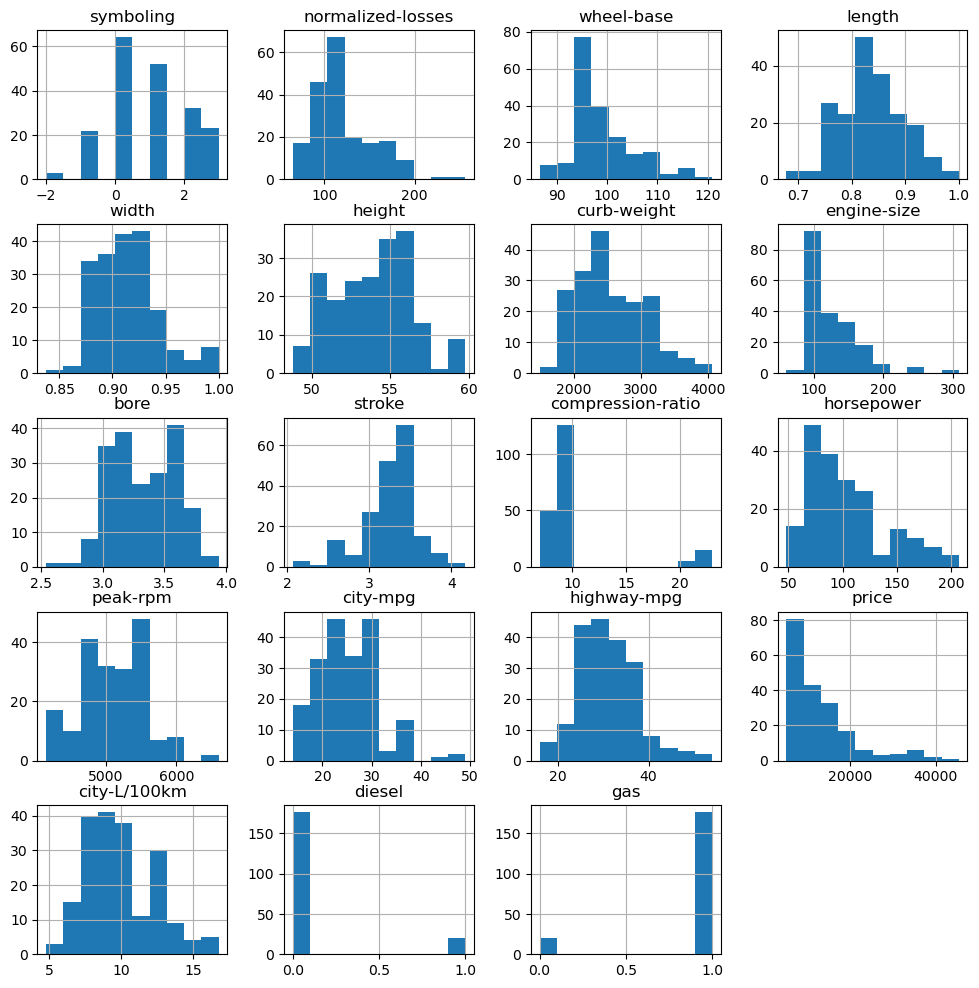

In [108]:
df[var_numericas].hist(layout=(5,4), sharex=False, sharey=False, figsize=(12,12))
plt.show()

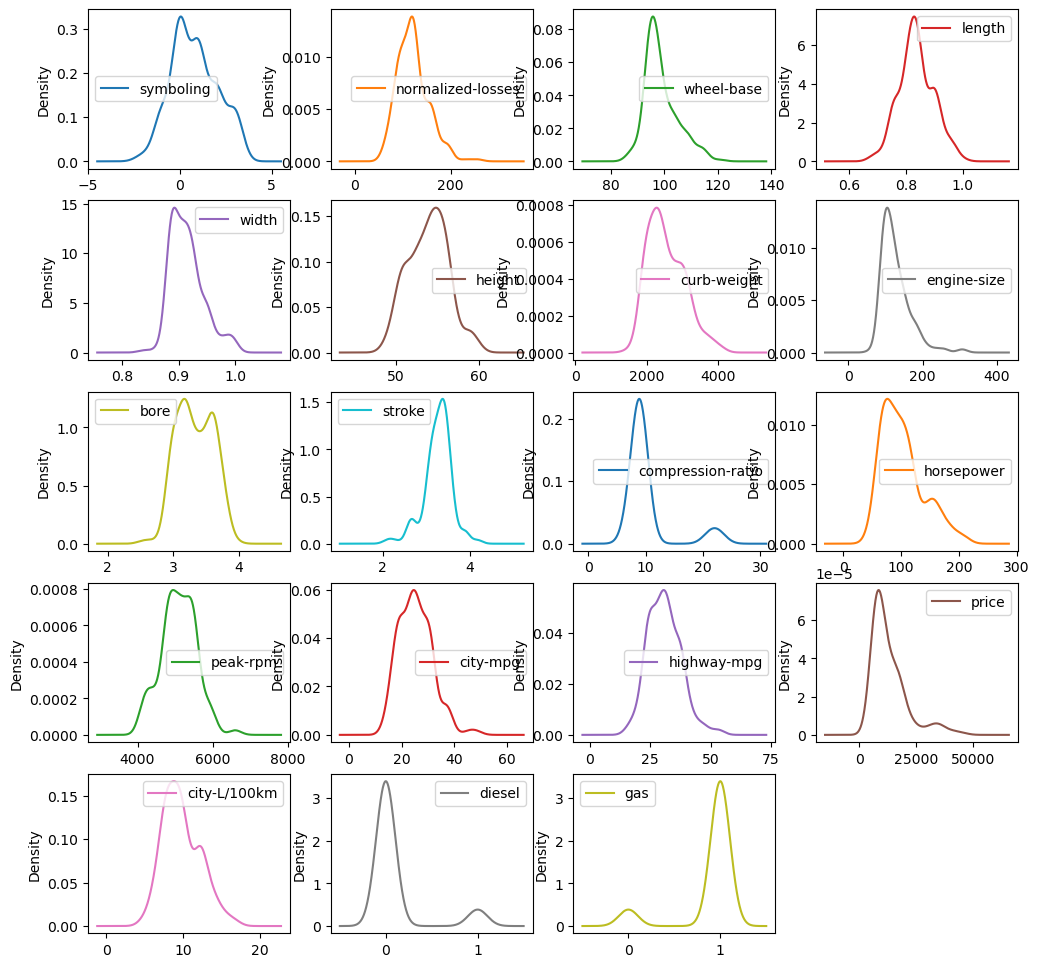

In [109]:
df[var_numericas].plot(kind='density', subplots=True, layout=(5,4), sharex=False, sharey=False, figsize=(12,12))
plt.show()

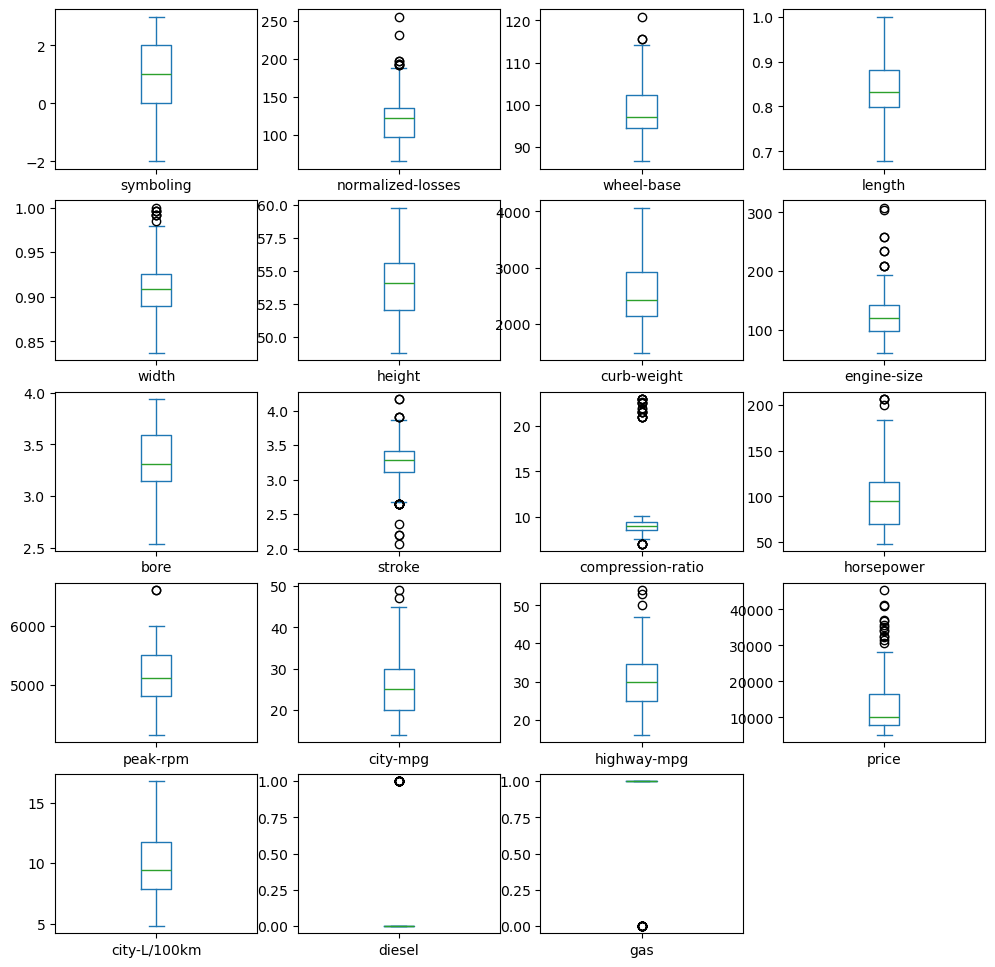

In [110]:
df[var_numericas].plot(kind='box', subplots=True, layout=(5,4), sharex=False, sharey=False, figsize=(12,12))
plt.show()

### 3.- Graficando diagramas de dispersión

/opt/anaconda3/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


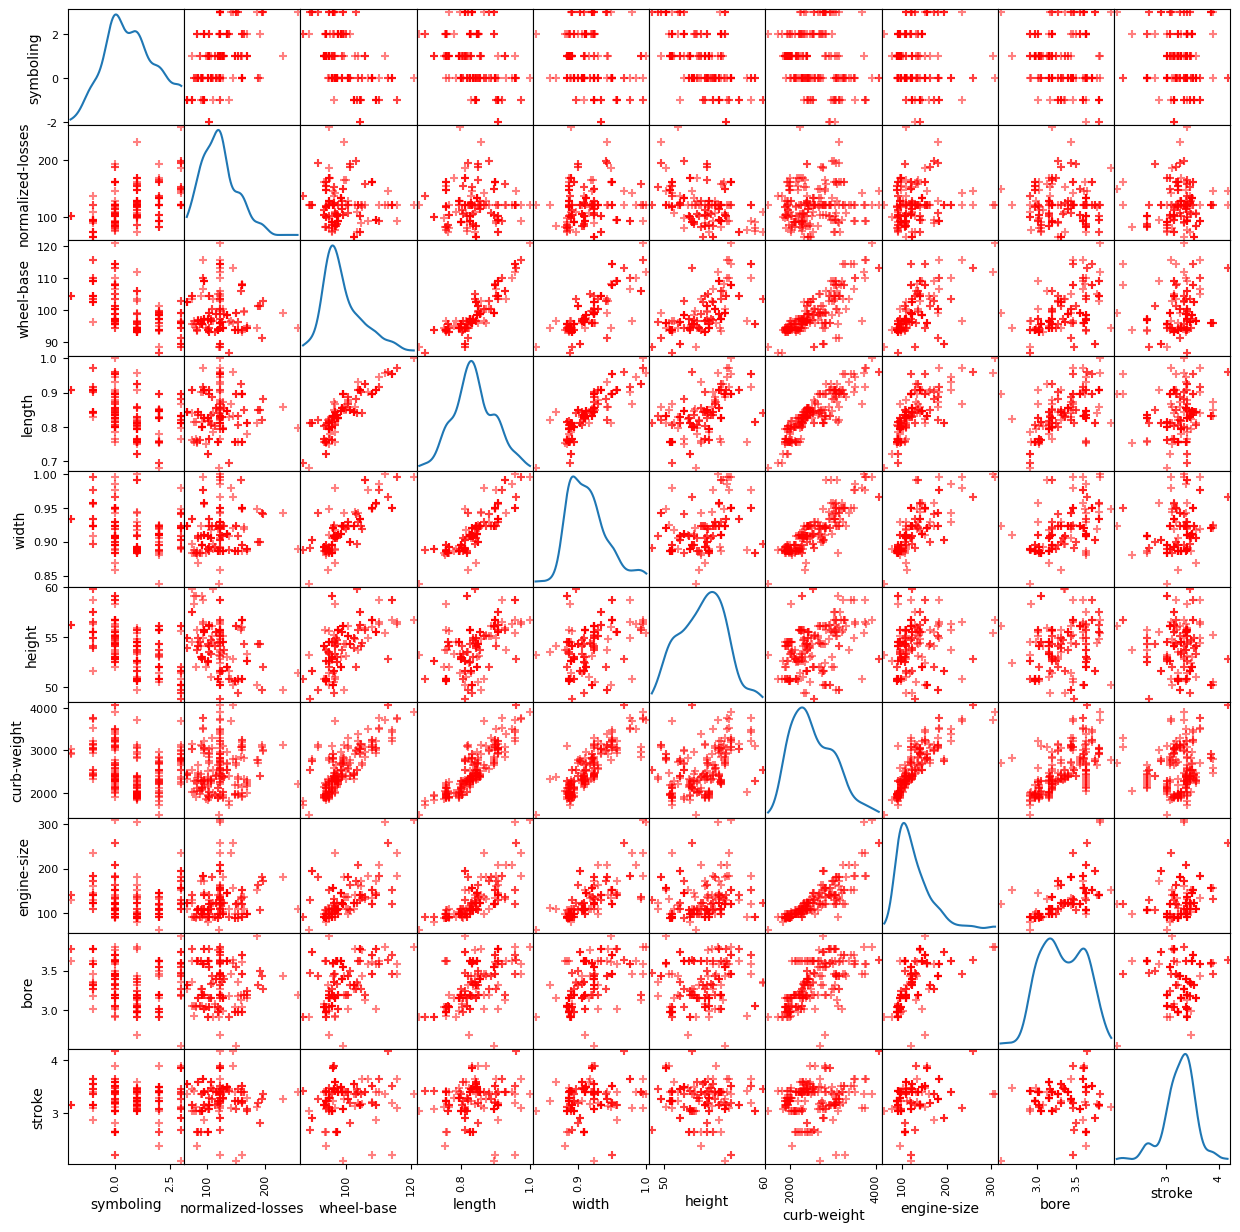

In [111]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[var_numericas].iloc[:,0:10], figsize=(15,15), color='red',
               diagonal='kde', marker="+")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


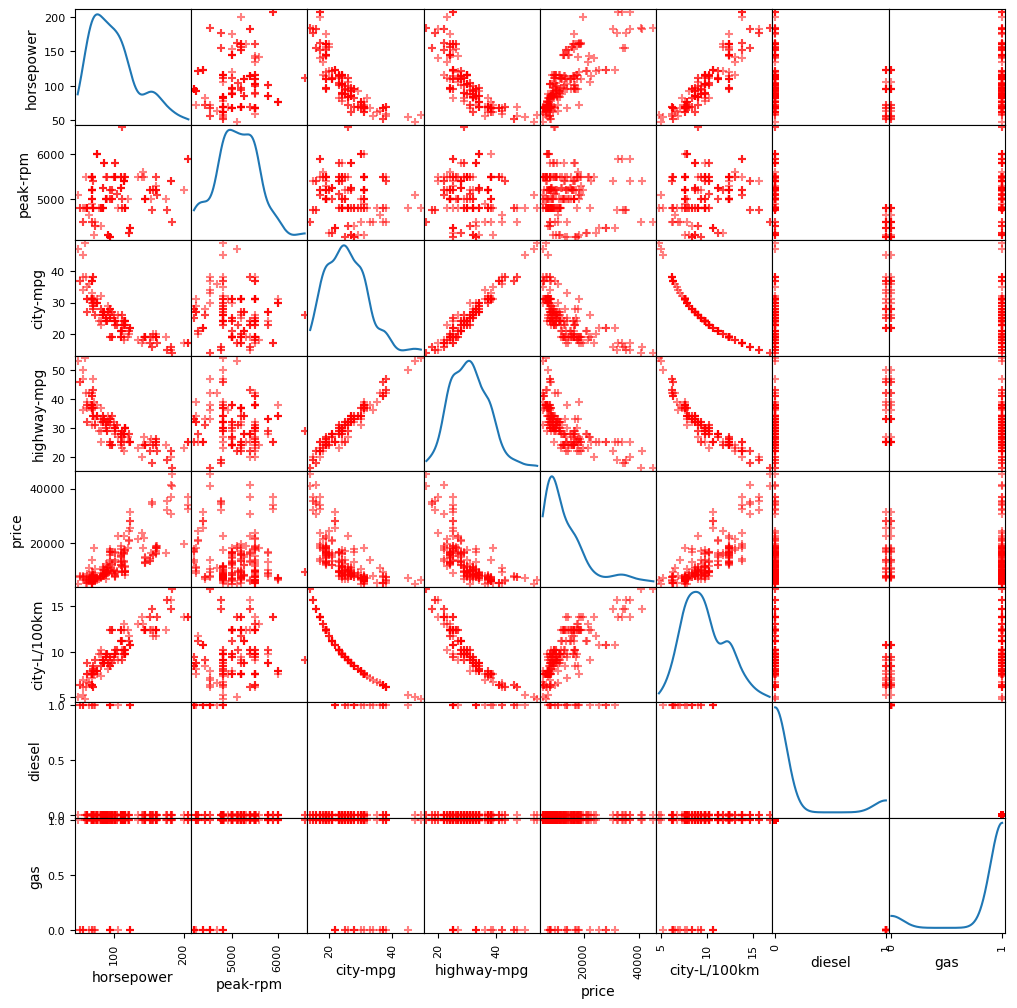

In [112]:
scatter_matrix(df[var_numericas].iloc[:,11:len(var_numericas)], figsize=(12,12), color='red',
               diagonal='kde', marker="+")
plt.show()

### 4.- Graficando matriz de correlación y mapa de calor

In [113]:
df[var_numericas].corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.453423,-0.533112,-0.359883,-0.242821,-0.539407,-0.226121,-0.055329,-0.142125,-0.013520,-0.180275,0.090778,0.229436,0.004688,0.073359,-0.076420,0.021612,-0.192544,0.192544
normalized-losses,0.453423,1.000000,-0.046971,0.027234,0.090056,-0.362499,0.107034,0.147862,-0.030152,0.056054,-0.112288,0.226654,0.215903,-0.208695,-0.166772,0.138183,0.223308,-0.096487,0.096487
wheel-base,-0.533112,-0.046971,1.000000,0.876945,0.821427,0.607417,0.790205,0.592517,0.493941,0.163725,0.248383,0.381984,-0.351925,-0.496565,-0.566948,0.591956,0.517050,0.305889,-0.305889
length,-0.359883,0.027234,0.876945,1.000000,0.857249,0.522367,0.882091,0.698626,0.608496,0.136850,0.156926,0.583073,-0.280397,-0.686142,-0.715124,0.689466,0.690579,0.212484,-0.212484
width,-0.242821,0.090056,0.821427,0.857249,1.000000,0.351127,0.862835,0.739543,0.543859,0.210495,0.188331,0.604099,-0.252116,-0.639692,-0.684550,0.744176,0.685663,0.251112,-0.251112
height,-0.539407,-0.362499,0.607417,0.522367,0.351127,1.000000,0.354085,0.100518,0.199490,-0.084755,0.269773,-0.031489,-0.270020,-0.128523,-0.181670,0.182407,0.111120,0.279063,-0.279063
curb-weight,-0.226121,0.107034,0.790205,0.882091,0.862835,0.354085,1.000000,0.858968,0.646918,0.193575,0.153952,0.750749,-0.281231,-0.766146,-0.808146,0.828483,0.809512,0.228445,-0.228445
engine-size,-0.055329,0.147862,0.592517,0.698626,0.739543,0.100518,0.858968,1.000000,0.601384,0.265626,0.017246,0.825377,-0.227577,-0.712693,-0.734062,0.889265,0.814696,0.076032,-0.076032
bore,-0.142125,-0.030152,0.493941,0.608496,0.543859,0.199490,0.646918,0.601384,1.000000,-0.049606,-0.000044,0.579114,-0.276668,-0.591597,-0.598455,0.544375,0.574286,0.055927,-0.055927
stroke,-0.013520,0.056054,0.163725,0.136850,0.210495,-0.084755,0.193575,0.265626,-0.049606,1.000000,0.191776,0.139409,-0.067852,-0.050971,-0.052345,0.107893,0.065893,0.240193,-0.240193


In [114]:
custom_var = ['bore','stroke','compression-ratio','horsepower','wheel-base','length'	]
df[custom_var].corr()

,bore,stroke,compression-ratio,horsepower,wheel-base,length
bore,1.000000,-0.049606,-0.000044,0.579114,0.493941,0.608496
stroke,-0.049606,1.000000,0.191776,0.139409,0.163725,0.136850
compression-ratio,-0.000044,0.191776,1.000000,-0.232284,0.248383,0.156926
horsepower,0.579114,0.139409,-0.232284,1.000000,0.381984,0.583073
wheel-base,0.493941,0.163725,0.248383,0.381984,1.000000,0.876945
length,0.608496,0.136850,0.156926,0.583073,0.876945,1.000000


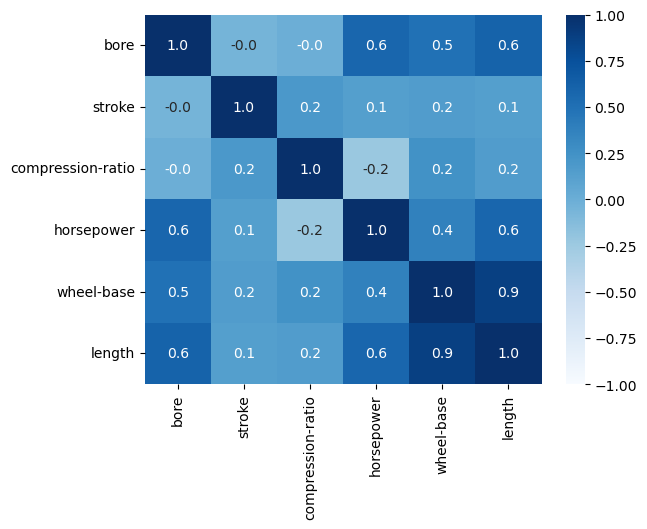

In [115]:
sns.heatmap(df[custom_var].corr(), vmin=-1,vmax=1, annot=True, fmt='.1f', cmap='Blues')
plt.show()

### 5.- Función para graficar mapa de calor

In [116]:
def heatmap_corr(lista):
    corr = df[lista].corr(method='pearson')
    corr1 = corr.to_numpy()
    fig, ax = plt.subplots(figsize=(8,8))
    cax = ax.imshow(corr1, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(lista)))
    ax.set_yticks(np.arange(len(lista)))
    ax.set_xticklabels(lista, rotation=45, ha='right')
    ax.set_yticklabels(lista)
    for i in range(len(lista)):
        for j in range(len(lista)):
            text = ax.text(j, i, f"{corr1[i, j]:.2f}",
                           ha="center", va="center", color="w" if abs(corr1[i, j]) > 0.5 else "black")
    fig.colorbar(cax)
    plt.title("Heatmap de Correlación")
    plt.show()

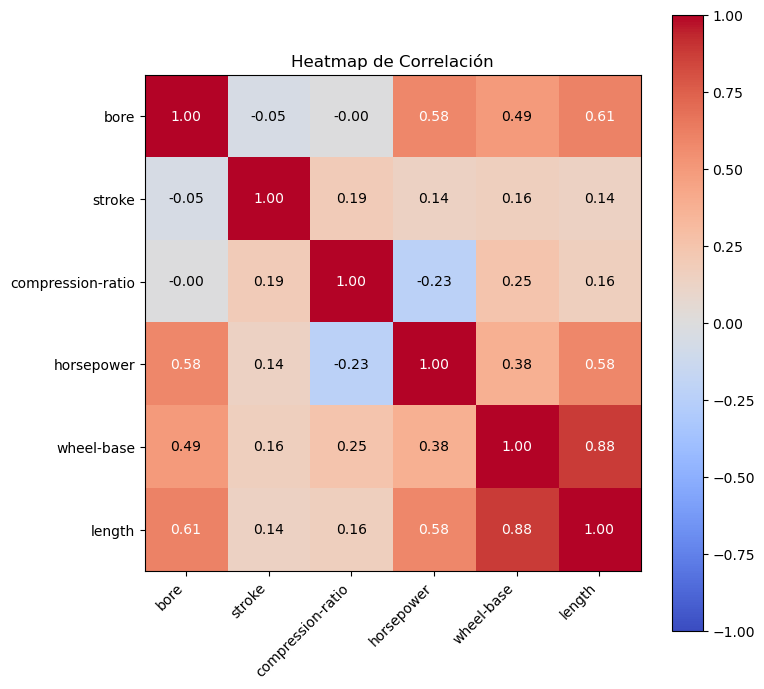

In [117]:
heatmap_corr(custom_var)

### 7.- Relaciones lineales entre variables

<Axes: xlabel='engine-size', ylabel='price'>

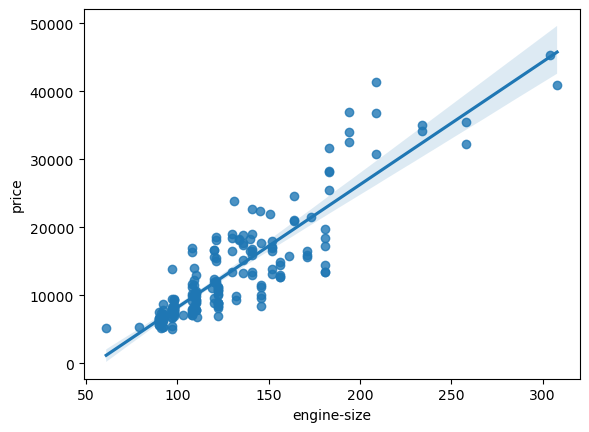

In [118]:
sns.regplot(x='engine-size', y='price', data=df)

In [119]:
df[['engine-size', 'price']].corr()

,engine-size,price
engine-size,1.000000,0.889265
price,0.889265,1.000000


### 8.- Analizando la relación entre variables categóricas y la variable dependiente

<Axes: xlabel='body-style', ylabel='price'>

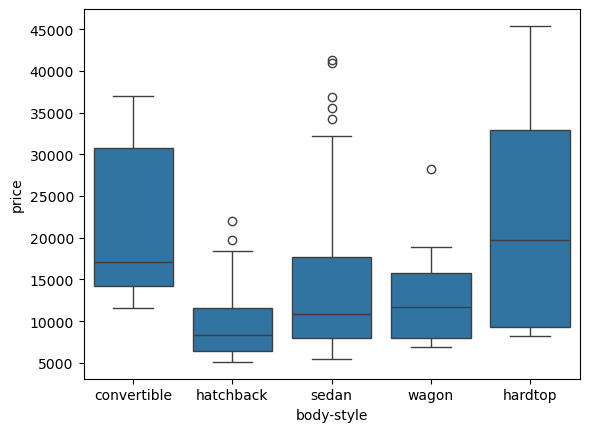

In [120]:
sns.boxplot(x='body-style', y='price', data=df)

Interpretación 1 :
- Modelos más caros son el Hardtop y Convertible
- Los modelos de Sedan son más accesibles
- los Hatchback son los mas baratos o económicos, menos variabilidad de los precios , y menores en precio al sedan

Interpretación 2 :
- Se observa que los autos hardtop y convertible tienden a tener precios más altos, mientras que los hatchback presentan los precios más bajos. Los sedan y wagon tienen precios intermedios. Además, se observan algunos valores atípicos especialmente en sedan

<Axes: xlabel='engine-location', ylabel='price'>

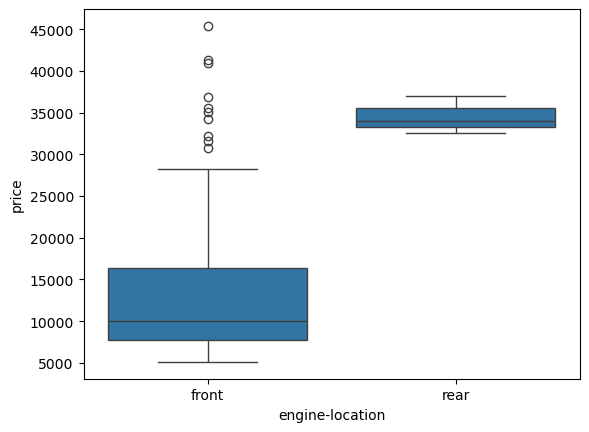

In [121]:
sns.boxplot(x='engine-location', y='price', data=df)

Interpretaciones :
- Los autos que tiene el motor en la parte posterior del auto, son los más caros

<Axes: xlabel='drive-wheels', ylabel='price'>

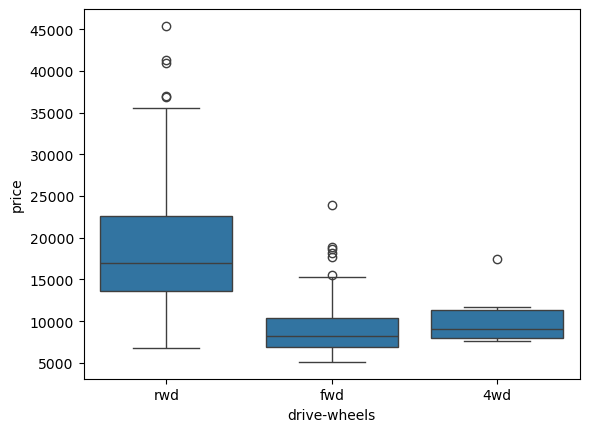

In [122]:
sns.boxplot(x='drive-wheels', y='price', data=df)

<Axes: xlabel='num-of-cylinders', ylabel='price'>

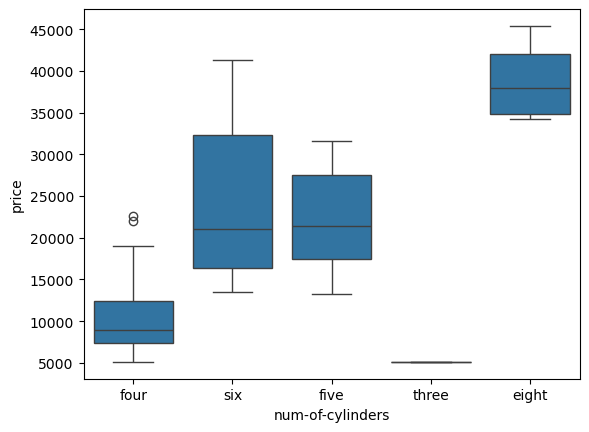

In [123]:
sns.boxplot(x='num-of-cylinders', y='price', data=df)

<Axes: xlabel='fuel-system', ylabel='price'>

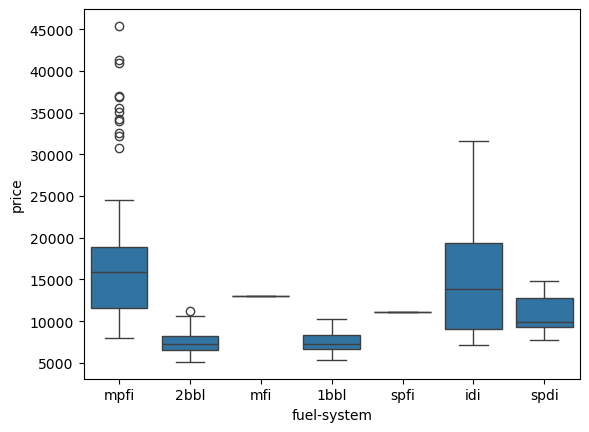

In [124]:
sns.boxplot(x='fuel-system', y='price', data=df)

### 10.- Conteo de frecuencias en variables categóricas

In [125]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
# drive_wheels_counts.rename(columns={'drive-wheels':'value_counts'}, inplace=True)
# drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts.head() 

,count
drive-wheels,
fwd,118
rwd,70
4wd,8


In [126]:
drive_wheels_counts = df['engine-location'].value_counts().to_frame()
# drive_wheels_counts.rename(columns={'engine-location':'value_counts'}, inplace=True)
# drive_wheels_counts.index.name = 'engine-location'
drive_wheels_counts.head() 

,count
engine-location,
front,193
rear,3


### 11.- Agrupamiento de columnas

In [127]:
df_group = df[['drive-wheels','price']]
df_group.head()

,drive-wheels,price
0,rwd,13495.0
1,rwd,16500.0
2,rwd,16500.0
3,fwd,13950.0
4,4wd,17450.0


In [128]:
df_group_one = df_group.groupby(['drive-wheels'], as_index=False).mean()
df_group_one.head()
# df_grouped.rename(columns={'price':'mean_price'}, inplace=True)
# df_pivot = df_grouped.pivot(index='drive-wheels', columns='body-style

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19910.585714


In [129]:
df_group = df[['drive-wheels','body-style','price']]
df_group.head()


,drive-wheels,body-style,price
0,rwd,convertible,13495.0
1,rwd,convertible,16500.0
2,rwd,hatchback,16500.0
3,fwd,sedan,13950.0
4,4wd,sedan,17450.0


In [130]:
df_group_two = df_group.groupby(['drive-wheels','body-style'], as_index=False).mean()
df_group_two.head()

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000


### 12 .- Agrupamiento de columnas con pivot

In [131]:
df_gptest1 = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest1.groupby(['drive-wheels','body-style'], as_index=False).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


In [132]:
grouped_pivot1 = grouped_test1.pivot(index='drive-wheels', columns='body-style')
grouped_pivot1.head()

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14714.285714  21303.600000   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [133]:
grouped_pivot1 = grouped_pivot1.fillna(0)
grouped_pivot1 = round(grouped_pivot1, 2)
grouped_pivot1

price                                        
body-style   convertible   hardtop hatchback     sedan     wagon
drive-wheels                                                    
4wd                  0.0      0.00   7603.00  12647.33   9095.75
fwd              11595.0   8249.00   8396.39   9811.80   9997.33
rwd              23949.6  24202.71  14714.29  21303.60  16994.22

In [134]:
df_gptest2 = df[['fuel-system','num-of-cylinders','price']]
grouped_test2 = df_gptest2.groupby(['fuel-system','num-of-cylinders'], as_index=False).mean()
grouped_test2

,fuel-system,num-of-cylinders,price
0,1bbl,four,7555.545455
1,2bbl,four,7469.428571
2,2bbl,three,5151.000000
3,idi,five,28394.000000
4,idi,four,12047.800000
5,idi,six,22470.000000
6,mfi,four,12964.000000
7,mpfi,eight,38900.000000
8,mpfi,five,17750.000000
9,mpfi,four,13338.140351


In [135]:
grouped_pivot2 = grouped_test2.pivot(index='fuel-system', columns='num-of-cylinders')
grouped_pivot2

price                                             
num-of-cylinders    eight     five          four           six   three
fuel-system                                                           
1bbl                  NaN      NaN   7555.545455           NaN     NaN
2bbl                  NaN      NaN   7469.428571           NaN  5151.0
idi                   NaN  28394.0  12047.800000  22470.000000     NaN
mfi                   NaN      NaN  12964.000000           NaN     NaN
mpfi              38900.0  17750.0  13338.140351  23724.086957     NaN
spdi                  NaN      NaN  10990.444444           NaN     NaN
spfi                  NaN      NaN  11048.000000           NaN     NaN

In [136]:
grouped_pivot2 = grouped_pivot2.fillna(0)
grouped_pivot2 = round(grouped_pivot2, 2)

grouped_pivot2

price                                     
num-of-cylinders    eight     five      four       six   three
fuel-system                                                   
1bbl                  0.0      0.0   7555.55      0.00     0.0
2bbl                  0.0      0.0   7469.43      0.00  5151.0
idi                   0.0  28394.0  12047.80  22470.00     0.0
mfi                   0.0      0.0  12964.00      0.00     0.0
mpfi              38900.0  17750.0  13338.14  23724.09     0.0
spdi                  0.0      0.0  10990.44      0.00     0.0
spfi                  0.0      0.0  11048.00      0.00     0.0

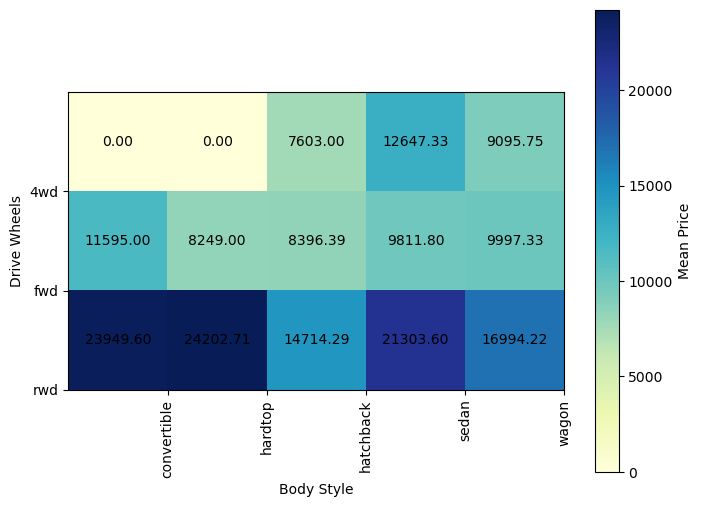

In [137]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(grouped_pivot1, cmap='YlGnBu')

row_labels = grouped_pivot1.columns.get_level_values(1)
col_labels = grouped_pivot1.index

ax.set_xticks(np.arange(grouped_pivot1.shape[1]) + 0.5 , minor=False)
ax.set_yticks(np.arange(grouped_pivot1.shape[0]) + 0.5 , minor=False)
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)  

ax.set_ylabel('Drive Wheels')
ax.set_xlabel('Body Style')

plt.xticks(rotation=90)
fig.colorbar(im, label='Mean Price')

for y in range(grouped_pivot1.shape[0]):
    for x in range(grouped_pivot1.shape[1]):
        plt.text(x , y , '%.2f' % grouped_pivot1.iloc[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 color='black')

plt.show()


In [138]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.00000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000
mean,0.801020,121.428571,98.852041,0.837183,0.914846,53.882143,2551.50000,126.969388,3.329643,3.259439,10.173061,102.472002,5100.258872,25.413265,30.913265,13094.658163,9.819073,0.102041,0.897959
std,1.230467,32.149650,6.118651,0.059556,0.029181,2.365031,513.79767,38.807468,0.271071,0.318079,4.053371,36.012855,467.021518,6.327606,6.738913,7875.984533,2.426332,0.303477,0.303477
min,-2.000000,65.000000,86.600000,0.678039,0.837500,48.800000,1488.00000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,14.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,97.250000,94.500000,0.799135,0.889931,52.000000,2145.00000,98.000000,3.150000,3.110000,8.500000,70.000000,4800.000000,20.000000,25.000000,7765.750000,7.833333,0.000000,1.000000
50%,1.000000,122.000000,97.000000,0.832292,0.909028,54.100000,2417.00000,120.000000,3.310000,3.290000,9.000000,95.000000,5112.684729,25.000000,30.000000,10096.500000,9.400000,0.000000,1.000000
75%,2.000000,134.750000,102.400000,0.881788,0.926042,55.625000,2928.25000,142.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.500000,16500.750000,11.750000,0.000000,1.000000
max,3.000000,256.000000,120.900000,1.000000,1.000000,59.800000,4066.00000,308.000000,3.940000,4.170000,23.000000,207.000000,6600.000000,49.000000,54.000000,45400.000000,16.785714,1.000000,1.000000


In [139]:
df[var_numericas].describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.00000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000
mean,0.801020,121.428571,98.852041,0.837183,0.914846,53.882143,2551.50000,126.969388,3.329643,3.259439,10.173061,102.472002,5100.258872,25.413265,30.913265,13094.658163,9.819073,0.102041,0.897959
std,1.230467,32.149650,6.118651,0.059556,0.029181,2.365031,513.79767,38.807468,0.271071,0.318079,4.053371,36.012855,467.021518,6.327606,6.738913,7875.984533,2.426332,0.303477,0.303477
min,-2.000000,65.000000,86.600000,0.678039,0.837500,48.800000,1488.00000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,14.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,97.250000,94.500000,0.799135,0.889931,52.000000,2145.00000,98.000000,3.150000,3.110000,8.500000,70.000000,4800.000000,20.000000,25.000000,7765.750000,7.833333,0.000000,1.000000
50%,1.000000,122.000000,97.000000,0.832292,0.909028,54.100000,2417.00000,120.000000,3.310000,3.290000,9.000000,95.000000,5112.684729,25.000000,30.000000,10096.500000,9.400000,0.000000,1.000000
75%,2.000000,134.750000,102.400000,0.881788,0.926042,55.625000,2928.25000,142.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.500000,16500.750000,11.750000,0.000000,1.000000
max,3.000000,256.000000,120.900000,1.000000,1.000000,59.800000,4066.00000,308.000000,3.940000,4.170000,23.000000,207.000000,6600.000000,49.000000,54.000000,45400.000000,16.785714,1.000000,1.000000


In [140]:
# Solo variables categoricas
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,196,196,196,196,196,196,196,196,196,196
unique,22,2,2,5,3,2,5,5,7,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,160,115,93,118,193,145,157,90,112


# B.- Estadística Inferencial

### 1.- Prueba de hipótesis para correlación entre variables

In [141]:
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])

print("The Pearson Correlation coefficient is", round(pearson_coef, 2))
print("The p-value is", p_value)

The Pearson Correlation coefficient is 0.59
The p-value is 6.413338815390868e-20


Existe evidencia estadistica que hay correlación entre la variables wheel-base y price

In [142]:
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])

print("The Pearson Correlation coefficient is", round(pearson_coef, 2))
print("The p-value is", p_value)

The Pearson Correlation coefficient is 0.8
The p-value is 2.6864046676334563e-45


Existe evidencia estadistica que hay correlación entre la variables horsepower y price

In [143]:
pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])

print("The Pearson Correlation coefficient is", round(pearson_coef, 2))
print("The p-value is", p_value)

The Pearson Correlation coefficient is 0.69
The p-value is 5.531750161102464e-29


In [144]:
pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])

print("The Pearson Correlation coefficient is", round(pearson_coef, 2))
print("The p-value is", p_value)

The Pearson Correlation coefficient is 0.74
The p-value is 7.73654667713947e-36


### 2.- ANOVA

In [145]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [146]:
df[df["drive-wheels"] == "rwd"]["price"].head()

0     13495.0
1     16500.0
2     16500.0
9     16430.0
10    16925.0
Name: price, dtype: float64

In [147]:
df[df["drive-wheels"] == "fwd"]["price"].head()

3    13950.0
5    15250.0
6    17710.0
7    18920.0
8    23875.0
Name: price, dtype: float64

In [150]:
df[df["drive-wheels"] == "4wd"]["price"].head()

4      17450.0
136     7603.0
140     9233.0
141    11259.0
144     8013.0
Name: price, dtype: float64

In [151]:
# ANOVA
f_val, p_val = stats.f_oneway(df[df["drive-wheels"] == "fwd"]["price"], 
                              df[df["drive-wheels"] == "rwd"]["price"], 
                              df[df["drive-wheels"] == "4wd"]["price"])  
 
print( "ANOVA results: F=", f_val, ", p-value =", p_val) 

ANOVA results: F= 69.54140581577971 , p-value = 1.8030300682433396e-23


Con una puntuación de F-test grande que muestra una fuerte correlación y un p-valor cercano a 0, garantiza la significancia de la prueba estadística. Pero, ¿significa esto que los tres grupos probados están tan correlacionados?

## Aplicando ANOVA por pares de categorías


In [152]:
f_val, p_val = stats.f_oneway(df[df["drive-wheels"] == "fwd"]["price"], 
                              df[df["drive-wheels"] == "rwd"]["price"])  
 
print( "ANOVA results: F=", f_val, ", p-value =", p_val) 

ANOVA results: F= 133.68058112336752 , p-value = 1.1991081909665041e-23


In [153]:
f_val, p_val = stats.f_oneway(df[df["drive-wheels"] == "4wd"]["price"], 
                              df[df["drive-wheels"] == "rwd"]["price"])  
 
print( "ANOVA results: F=", f_val, ", p-value =", p_val)

ANOVA results: F= 8.918937140036293 , p-value = 0.003796935906545933


In [154]:
f_val, p_val = stats.f_oneway(df[df["drive-wheels"] == "4wd"]["price"], 
                              df[df["drive-wheels"] == "fwd"]["price"])  
 
print( "ANOVA results: F=", f_val, ", p-value =", p_val)

ANOVA results: F= 0.665465750252303 , p-value = 0.41620116697845666


<h3>Conclusión: Importantes Variables </h3>

<p> Ahora tenemos una mejor idea de cómo se ven nuestros datos y qué variables son importantes para tener en cuenta al predecir el precio del automóvil. Lo hemos reducido a las siguientes variables: </p>

Variables numéricas continuas:
<ul>
    <li>Length</li>
    <li>Width</li>
    <li>Curb-weight</li>
    <li>Engine-size</li>
    <li>Horsepower</li>
    <li>City-mpg</li>
    <li>Highway-mpg</li>
    <li>Wheel-base</li>
    <li>Bore</li>
</ul>
    
Variables categóricas:
<ul>
    <li>drive-wheels</li>
</ul>